In [28]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df=pd.read_csv("shoe_sales.csv")
df.head()

,date,brand,sold_qty
0,9/1/2023,Nike,24.0
1,9/1/2023,Adidas,14.0
2,9/2/2023,Nike,21.0
3,9/2/2023,Adidas,12.0
4,9/3/2023,Nike,18.0


In [4]:
 df.shape

(60, 3)

In [5]:
df.describe()

,sold_qty
count,58.000000
mean,27.482759
std,88.519844
min,7.000000
25%,12.250000
50%,16.000000
75%,19.750000
max,689.000000


In [7]:
df[df["sold_qty"]<12.25].shape # 25% of 60

(15, 3)

### 1. Nike Analysis

In [9]:
df_nike=df[df["brand"]=="Nike"]
df_nike.shape

(30, 3)

In [10]:
df_nike.describe()

,sold_qty
count,28.000000
mean,19.642857
std,3.117624
min,14.000000
25%,17.000000
50%,19.500000
75%,22.000000
max,25.000000


In [13]:
round(df_nike["sold_qty"].median())

20

In [14]:
# checking null value in specific column
df_nike[df_nike["sold_qty"].isnull()]

,date,brand,sold_qty
32,9/17/2023,Nike,NaN
48,9/25/2023,Nike,NaN


In [16]:
val=round(df_nike["sold_qty"].median())
val

20

In [18]:
df_nike["sold_qty"].fillna(val, inplace=True)
df_nike.loc[[32,48]]

C:\Users\User\AppData\Local\Temp\ipykernel_11692\3050501957.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nike["sold_qty"].fillna(val, inplace=True)


,date,brand,sold_qty
32,9/17/2023,Nike,20.0
48,9/25/2023,Nike,20.0


In [22]:
# total shoe sales in month of sept
df_nike["sold_qty"].sum()

590.0

### 2. Adidas Analysis

In [20]:
df_adidas=df[df["brand"]=="Adidas"]
df_adidas.shape

(30, 3)

In [21]:
df_adidas.describe()

,sold_qty
count,30.000000
mean,34.800000
std,123.602366
min,7.000000
25%,10.000000
50%,12.500000
75%,15.000000
max,689.000000


In [23]:
df_adidas["sold_qty"].median()

12.5

In [24]:
# using percentile to find outliers
df_adidas["sold_qty"].quantile([0.95])

0.95    18.55
Name: sold_qty, dtype: float64

In [25]:
df_adidas[df_adidas["sold_qty"]>18.55]

,date,brand,sold_qty
23,9/12/2023,Adidas,689.0
39,9/20/2023,Adidas,19.0


In [31]:
def plot_qty():
    plt.figure(figsize=(15,6))

    dates=df_nike["date"]
    plt.plot(dates,df_nike["sold_qty"],marker="o", label="Nike", color="blue")
    plt.plot(dates,df_adidas["sold_qty"],marker="o",label="Adidas",color="red")

    plt.xlabel("Date")
    plt.ylabel("Total Qty Sold")
    plt.title("Daily sales qty for nike and adidas in sept 2023")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.show()

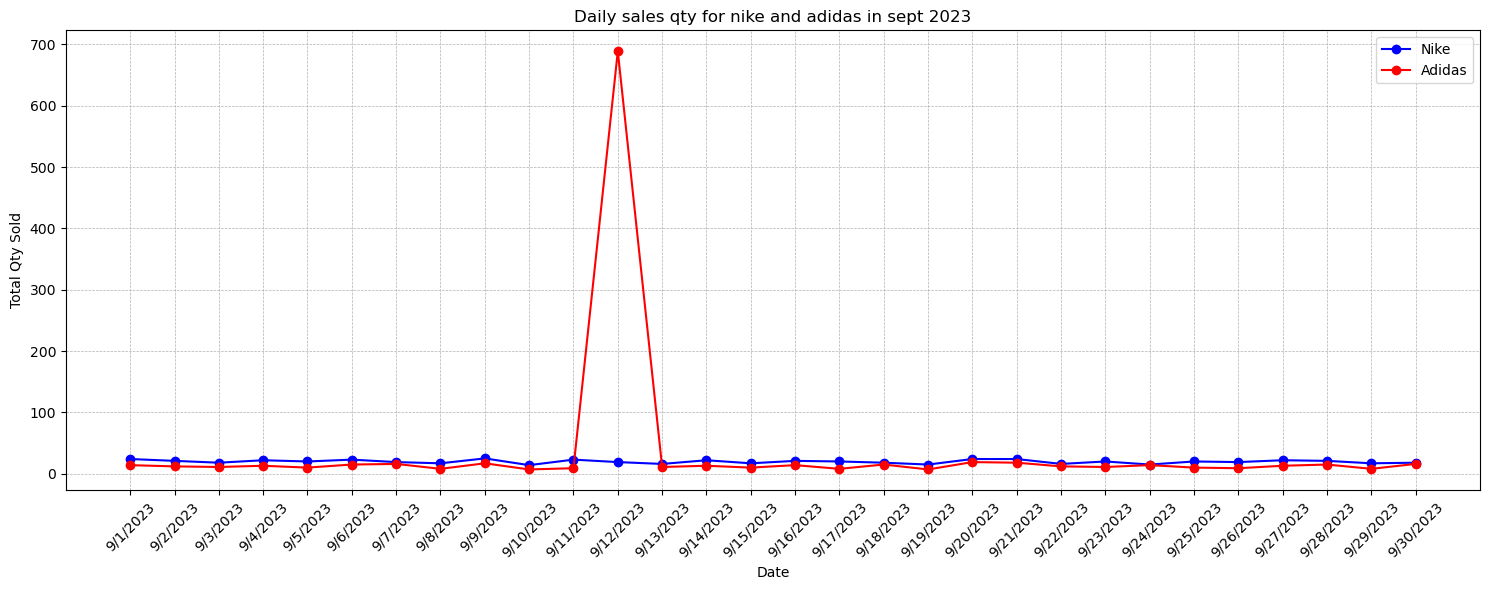

In [32]:
plot_qty()

In [34]:
val=round(df_adidas["sold_qty"].median())
val

12

In [35]:
df_adidas["sold_qty"].replace(689,val,inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_11692\1103430258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adidas["sold_qty"].replace(689,val,inplace=True)


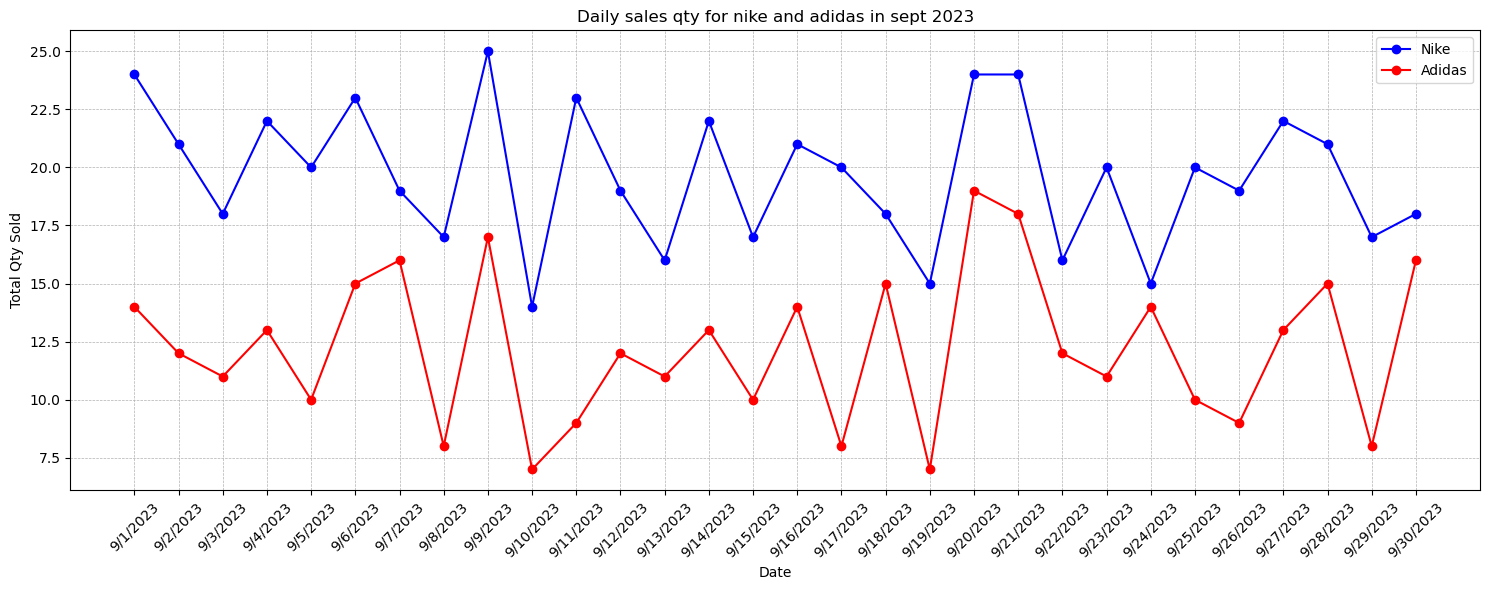

In [37]:
plot_qty()

In [ ]:
# insights that we got from this dataset
                                 nike           adidas
average daily units sold:         20              12
daily min and max sales        14 to 25        7 to 19
total shoes sold                 590             367

### 5.9 Outlier treatment using IQR and Box PLot

In [38]:
import pandas as pd

In [39]:
df=pd.read_csv("chapter4_assets/7_outlier_detection_using_iqr_boxplot/heights.csv")

In [40]:
df.head()

,name,height
0,mohan,1.2
1,maria,4.6
2,sakib,4.9
3,tao,5.1
4,virat,5.2


In [41]:
# finding 25th percentile value and 75th percentile value
Q1,Q3=df["height"].quantile([0.25,0.75])
Q1,Q3

(5.3500000000000005, 6.275)

In [48]:
# now calculating IQR
IQR=Q3-Q1
round(IQR,4)

0.925

In [46]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
lower,upper

(3.962500000000001, 7.6625)

In [50]:
df[(df["height"]<lower)|(df["height"]>upper)]
df.shape

(20, 2)

In [56]:
df_new=df[(df["height"]>lower)&(df["height"]<upper)]

In [57]:
df_new

,name,height
1,maria,4.6
2,sakib,4.9
3,tao,5.1
4,virat,5.2
5,khusbu,5.4
6,dmitry,5.5
7,selena,5.5
8,john,5.6
9,imran,5.6
10,jose,5.8


In [59]:
df=pd.read_excel("chapter4_assets/7_outlier_detection_using_iqr_boxplot/region_wise_sales.xlsx")
df.head()

,Month,Year,Region,Sales
0,January,2022,APAC,36750
1,February,2022,APAC,36995
2,March,2022,APAC,18579
3,April,2022,APAC,37768
4,May,2022,APAC,23956


In [60]:
df["Region"].unique()

array(['APAC', 'Europe', 'Americas'], dtype=object)

In [62]:
df_apac=df[df["Region"]=="APAC"]
df_europe=df[df["Region"]=="Europe"]
df_america=df[df["Region"]=="Americas"]


In [65]:
def get_lower_upper(data):
    Q1,Q3=data["Sales"].quantile([0.25,0.75])
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    return lower,upper

In [66]:
lower,upper=get_lower_upper(df_apac)
lower,upper

(-737.125, 59747.875)

In [67]:
df_apac["Sales"].describe()

count       12.000000
mean     29762.166667
std       7725.522905
min      18579.000000
25%      21944.750000
50%      31215.500000
75%      37066.000000
max      38143.000000
Name: Sales, dtype: float64

In [69]:
lower,upper=get_lower_upper(df_europe)
lower,upper

(7306.875, 17665.875)

In [70]:
df_europe["Sales"].describe()
## here max is greater than upper limit i.e 23000 , so this is outlier hence we have
# to remove it

count       12.000000
mean     13147.583333
std       3549.568795
min       9665.000000
25%      11191.500000
50%      12044.000000
75%      13781.250000
max      23000.000000
Name: Sales, dtype: float64

In [71]:
df_europe[df_europe["Sales"]>upper]

,Month,Year,Region,Sales
21,October,2022,Europe,23000


In [72]:
val=df_europe["Sales"].median()
val

12044.0

In [75]:
df_europe["Sales"].replace(23000,val,inplace=True)
df_europe.loc[[21]]

C:\Users\User\AppData\Local\Temp\ipykernel_11692\714375865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_europe["Sales"].replace(23000,val,inplace=True)


,Month,Year,Region,Sales
21,October,2022,Europe,12044


In [76]:
lower,upper=get_lower_upper(df_america)
lower,upper

(16832.375, 38473.375)

In [77]:
df_america["Sales"].describe()
# so there no outlier in america df

count       12.000000
mean     28356.750000
std       3610.368556
min      23407.000000
25%      24947.750000
50%      28770.500000
75%      30358.000000
max      34102.000000
Name: Sales, dtype: float64

In [78]:
## box plot

In [80]:
# extracting data according to labels for x axis
labels=df["Region"].unique()
labels

array(['APAC', 'Europe', 'Americas'], dtype=object)

In [82]:
plot_data=[df["Sales"][df["Region"]==label].values for label in labels]
plot_data

[array([36750, 36995, 18579, 37768, 23956, 38143, 29132, 21961, 33299,
        37279, 21388, 21896], dtype=int64),
 array([ 9665, 10297, 11079, 13410, 11229, 15352, 13286, 11470, 11873,
        23000, 12215, 14895], dtype=int64),
 array([30247, 29284, 27904, 23407, 23716, 25077, 33649, 24560, 34102,
        28257, 30691, 29387], dtype=int64)]

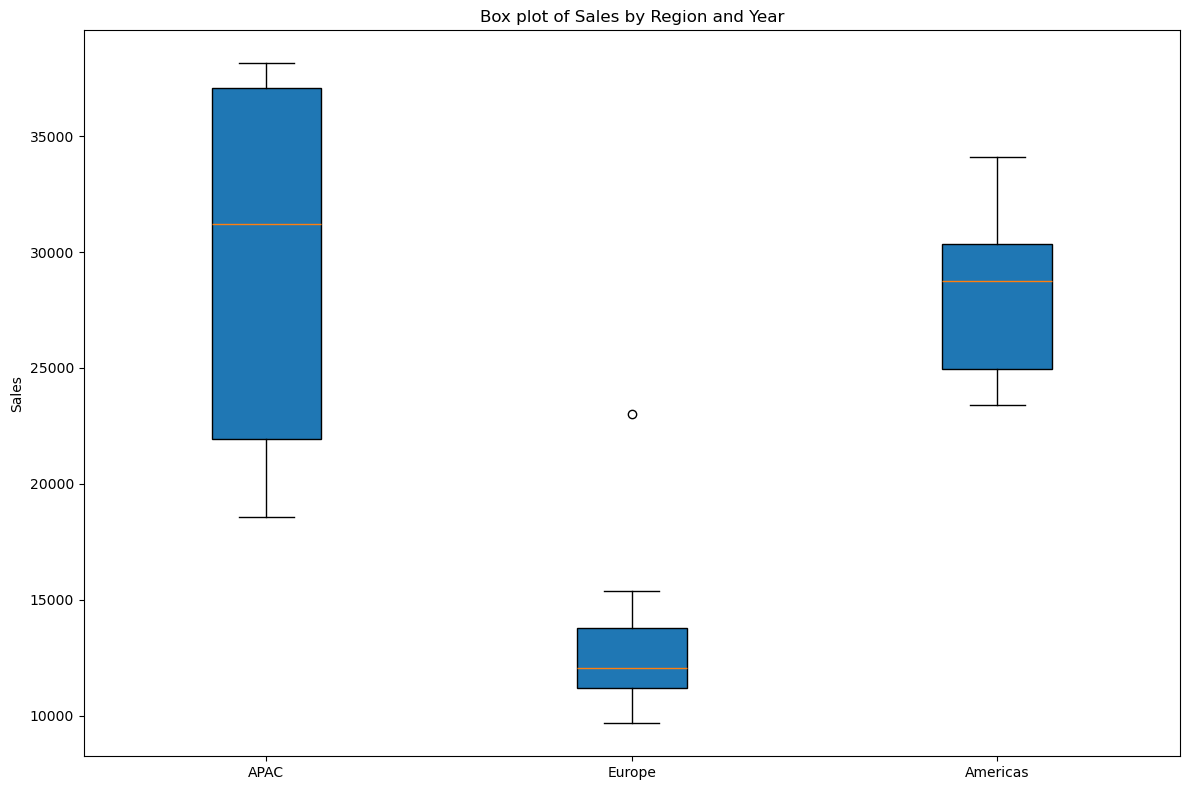

In [83]:
plt.figure(figsize=(12,8))
plt.boxplot(plot_data,labels=labels,vert=True,patch_artist=True)
plt.title("Box plot of Sales by Region and Year")
plt.ylabel("Sales")
#plt.xticks(rotation=)
plt.tight_layout()
plt.show()

## 5.13 Analysis: Stock Returns volatility (using variance and Std)

In [84]:
df=pd.read_csv("chapter4_assets/9_stock_returns_volatility/stock_returns.csv")
df

,year,nvidia_returns,reliance_returns
0,2016,122.14,47.43
1,2017,83.91,12.09
2,2018,-50.03,-13.63
3,2019,82.19,22.42
4,2020,125.84,62.59
5,2021,50.53,33.70
6,2022,48.57,10.26


In [86]:
df["nvidia_returns"].std(), df["nvidia_returns"].var()

(59.61166995847453, 3553.551195238095)

In [88]:
df["reliance_returns"].std(), round(df["reliance_returns"].var(),2)

(25.41216637754444, 645.78)